In [1]:
import xarray as xr
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
ds_18_7 = xr.open_mfdataset("/data/project/ARM_Summer_School_2026/data/modeling/lasso/20180709/sgplassodiagraw8C1.m1/raw_model/wrfout_d01_2018-07-*.nc", combine='nested', concat_dim = 'Time')
ds_19_5 = xr.open_mfdataset("/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190517/sgplassodiagraw4C1.m1/raw_model/wrfout_d01_2019-05-*.nc", combine='nested', concat_dim = 'Time')
ds_19_9 = xr.open_mfdataset("/data/project/ARM_Summer_School_2026/data/modeling/lasso/20190929/sgplassodiagraw4C1.m1/raw_model/wrfout_d01_2019-09-*.nc", combine='nested', concat_dim = 'Time')

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


In [3]:
datasets_raw = [ds_18_7, ds_19_5, ds_19_9]

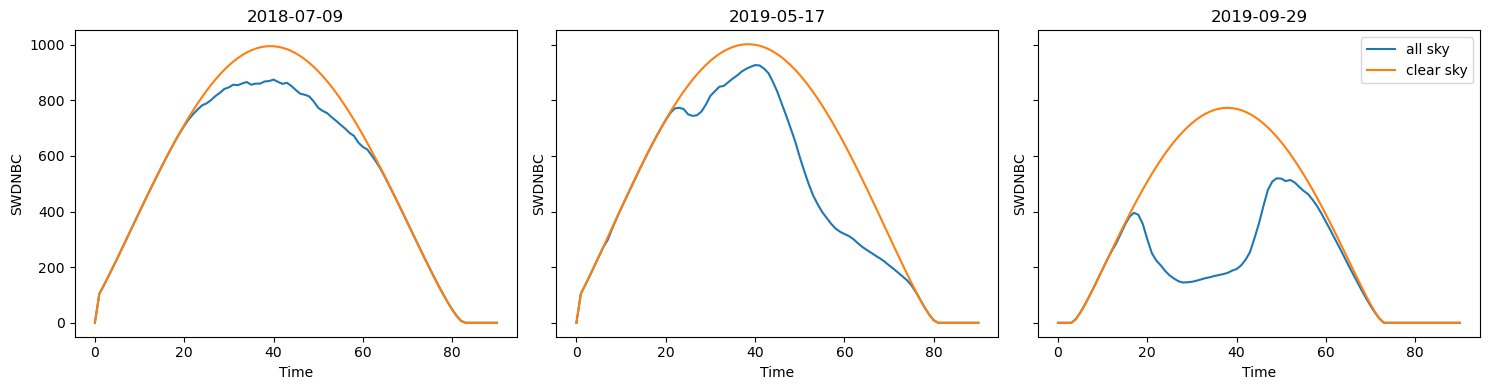

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (ax, ds) in enumerate(zip(axes, datasets_raw)):
  ds["SWDNB"].mean(['south_north', 'west_east']).plot(ax= ax, label = "all sky") 
  ds["SWDNBC"].mean(['south_north', 'west_east']).plot(ax = ax, label = "clear sky") 
  date_label = str(ds.XTIME.isel(Time=1).values)[:10]
  ax.set_title(date_label)

plt.legend()
plt.tight_layout()
plt.show()
